### 2.4 EDA Giải đấu và Tiền thưởng (Tournament & Prize Pool EDA)
- **Tập dữ liệu sử dụng:** `analysis_release_v1_20261005T194400349609Z`
- **Đơn vị quan sát:** Cấp Giải đấu (*Tournament*)

In [18]:
from pathlib import Path
import pandas as pd
from IPython.display import display

current_dir = Path.cwd().resolve()
release_name = "analysis_release_v1_20261005T194400349609Z"

ROOT = next(
    (
        folder
        for folder in [current_dir, *current_dir.parents]
        if (folder / "data/processed" / release_name).is_dir()
    ),
    None,
)

if ROOT is None:
    raise FileNotFoundError(
        "Không tìm thấy release. Hãy mở notebook trong project."
    )

RELEASE_DIR = ROOT / "data" / "processed" / release_name
INPUT_FILE = RELEASE_DIR / "tournaments.csv"

print("Release:", release_name)
print("File đầu vào:", INPUT_FILE)

Release: analysis_release_v1_20261005T194400349609Z
File đầu vào: D:\Semester_5\Project\esports-idv-analytics\data\processed\analysis_release_v1_20261005T194400349609Z\tournaments.csv


In [ ]:
earnings = pd.read_csv(
    INPUT_FILE,
    encoding="utf-8-sig",
    dtype={
        "tournament_id": "string",
        "source_tournament_id": "string",
        "prize_pool_usd": "string",
    },
)

print(f"Số dòng: {earnings.shape[0]:,}")
print(f"Số cột: {earnings.shape[1]}")

display(earnings.head(5))
earnings.info()

Số dòng: 14,082
Số cột: 37


,source_site,source_url,source_tournament_id,tournament_name_raw,location_raw,date_raw,start_date,end_date,game_name_raw,source_game_id,...,date_validation_status,crawler_status,eligible_for_placement_prize_analysis,quality_note,placements_total_usd,source_start_date,source_end_date,pool_cents,strict_quality,month_start
0,esportsearnings,https://www.esportsearnings.com/tournaments/52...,52681,CS Asia Championships 2023,"Shanghai, China",2023-11-08 to 2023-11-12,2023-11-08,2023-11-12,Counter-Strike 2,839,...,valid,matched,True,NaN,500000.00,NaN,NaN,50000000,True,2023-11-01
1,esportsearnings,https://www.esportsearnings.com/tournaments/52...,52728,AGS CUP 2023 (CS2),"Buenos Aires, Argentina",2023-10-13 to 2023-10-16,2023-10-13,2023-10-16,Counter-Strike 2,839,...,valid,matched,True,NaN,19999.28,NaN,NaN,1999928,True,2023-10-01
2,esportsearnings,https://www.esportsearnings.com/tournaments/52...,52741,Reliance Digital Level Up Mumbai 2023,"Mumbai, India",2023-10-18 to 2023-10-22,2023-10-18,2023-10-22,Counter-Strike 2,839,...,valid,matched,True,NaN,6010.00,NaN,NaN,601000,True,2023-10-01
3,esportsearnings,https://www.esportsearnings.com/tournaments/52...,52743,Aveiro Techdays Cup 2023,"Aveiro, Portugal",2023-10-06 to 2023-10-08,2023-10-06,2023-10-08,Counter-Strike 2,839,...,valid,needs_review,False,prize_allocation_pending_review,NaN,NaN,NaN,1052550,False,2023-10-01
4,esportsearnings,https://www.esportsearnings.com/tournaments/61...,61905,FACEIT CS2 10mans - March 2023,Online,2023-03-23 to 2023-04-01,2023-03-23,2023-04-01,Counter-Strike 2,839,...,valid,tournament_only,False,placements_unavailable_or_unapproved,NaN,NaN,NaN,500000,False,2023-03-01


<class 'pandas.DataFrame'>
RangeIndex: 14082 entries, 0 to 14081
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   source_site                            14082 non-null  str    
 1   source_url                             14082 non-null  str    
 2   source_tournament_id                   14082 non-null  int64  
 3   tournament_name_raw                    14082 non-null  str    
 4   location_raw                           14080 non-null  str    
 5   date_raw                               14082 non-null  str    
 6   start_date                             14082 non-null  str    
 7   end_date                               14082 non-null  str    
 8   game_name_raw                          14082 non-null  str    
 9   source_game_id                         14082 non-null  int64  
 10  game_source_url                        14082 non-null  str    
 11  prize_pool_ra

In [21]:
eda = earnings.copy()

eda["prize_pool_usd"] = pd.to_numeric(eda["prize_pool_usd"], errors="coerce")
eda["start_date"] = pd.to_datetime(eda["start_date"], errors="coerce")
eda["end_date"] = pd.to_datetime(eda["end_date"], errors="coerce")

check = pd.Series(
    {
        "ID giải thiếu": eda["tournament_id"].isna().sum(),
            "Dòng trùng ID giải": eda["tournament_id"].duplicated().sum(),
            "Nhóm game thiếu": eda["game_family"].isna().sum(),
            "Quỹ thưởng thiếu từ đầu": earnings["prize_pool_usd"].isna().sum(),
            "Quỹ thưởng không chuyển được sang số": (
                earnings["prize_pool_usd"].notna()
                & eda["prize_pool_usd"].isna()
            ).sum(),
            "Quỹ thưởng âm": eda["prize_pool_usd"].lt(0).sum(),
            "Quỹ thưởng bằng 0": eda["prize_pool_usd"].eq(0).sum(),
            "Ngày bắt đầu thiếu hoặc không hợp lệ": eda["start_date"].isna().sum(),
            "Ngày kết thúc thiếu hoặc không hợp lệ": eda["end_date"].isna().sum(),
            "Ngày kết thúc trước ngày bắt đầu": (
                eda["end_date"] < eda["start_date"]
            ).sum(),
    }
)

display(check.rename("Số dòng").to_frame())
print("Số giải theo game:")
display(eda["game_family"].value_counts(dropna=False).to_frame("Số giải"))

print(
    "Phạm vi ngày bắt đầu:",
    eda["start_date"].min(),
    "→",
    eda["start_date"].max(),
)

,Số dòng
ID giải thiếu,0
Dòng trùng ID giải,0
Nhóm game thiếu,0
Quỹ thưởng thiếu từ đầu,0
Quỹ thưởng không chuyển được sang số,0
Quỹ thưởng âm,0
Quỹ thưởng bằng 0,33
Ngày bắt đầu thiếu hoặc không hợp lệ,0
Ngày kết thúc thiếu hoặc không hợp lệ,0
Ngày kết thúc trước ngày bắt đầu,0


Số giải theo game:


,Số giải
game_family,
Counter-Strike,7938
League of Legends,2836
Dota 2,1977
Valorant,1331


Phạm vi ngày bắt đầu: 2012-01-04 00:00:00 → 2025-11-15 00:00:00


In [ ]:
summary = (
    eda.groupby("game_family", dropna=False)['prize_pool_usd'].agg(
        so_giai ="size",
        trung_binh_quy_thuong ="mean",
        trung_vi_quy_thuong ="median",
        q1_usd =lambda x: x.quantile(0.25),
        q3_usd =lambda x: x.quantile(0.75), 
        lon_nhat_usd ="max",
        do_lech_chuan_usd ="std",
    )
)

summary['iqr_usd'] = summary['q3_usd'] - summary['q1_usd']

display(summary.round(2))

,so_giai,trung_binh_quy_thuong,trung_vi_quy_thuong,q1_usd,q3_usd,lon_nhat_usd,do_lech_chuan_usd,iqr_usd
game_family,,,,,,,,
Counter-Strike,7938,26275.21,3412.31,1200.00,11582.52,2000000.0,106017.62,10382.52
Dota 2,1977,192498.70,10000.00,2197.50,50000.00,40018400.0,1691565.61,47802.50
League of Legends,2836,42798.83,4230.76,616.34,20000.00,6450000.0,240892.99,19383.66
Valorant,1331,26003.84,5000.00,1805.64,17500.00,2250000.0,120513.61,15694.36


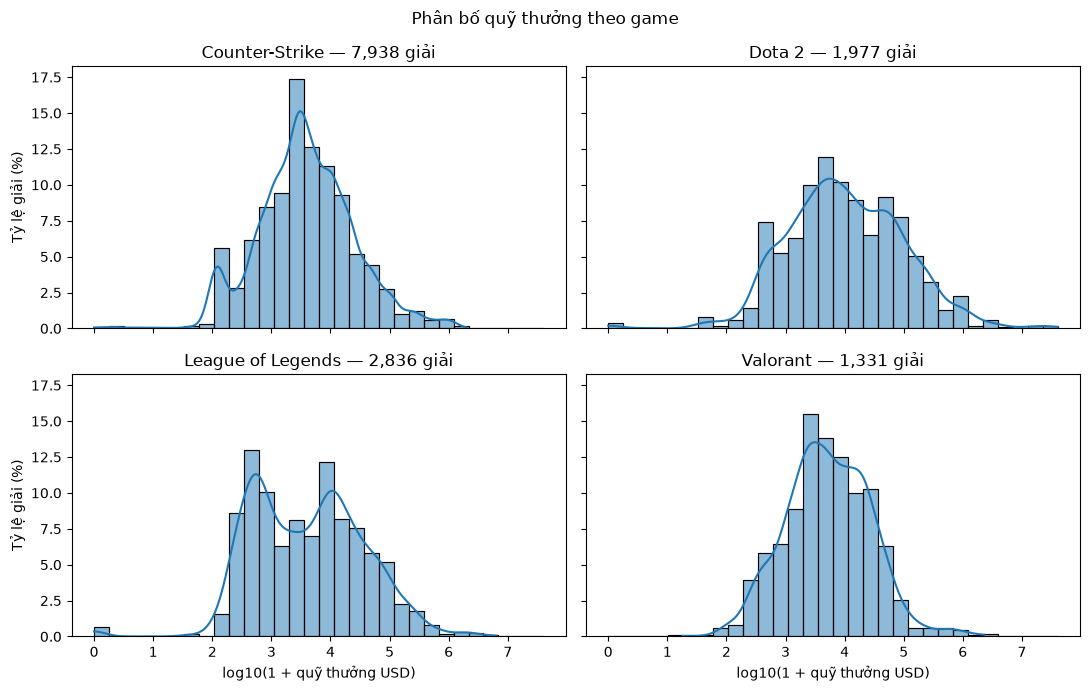

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = eda.copy()
plot_data['log_prize'] = np.log10(1 + plot_data['prize_pool_usd'])

games = ["Counter-Strike", "Dota 2", "League of Legends", "Valorant"]

bins = np.linspace(0, plot_data['log_prize'].max(), 31)

fig, axes = plt.subplots(
    2, 2, figsize=(11, 7), sharex=True, sharey=True
)

for ax, game in zip(axes.flat, games):
    values = plot_data.loc[
        plot_data["game_family"].eq(game), "log_prize"
    ]

    sns.histplot(
        x=values,
        bins=bins,
        stat="percent",
        kde=True,
        kde_kws={"cut": 0, "bw_adjust": 1},
        ax=ax,
    )

    ax.set_title(f"{game} — {len(values):,} giải")
    ax.set_xlabel("log10(1 + quỹ thưởng USD)")
    ax.set_ylabel("Tỷ lệ giải (%)")

fig.suptitle("Phân bố quỹ thưởng theo game")
fig.tight_layout()
plt.show()


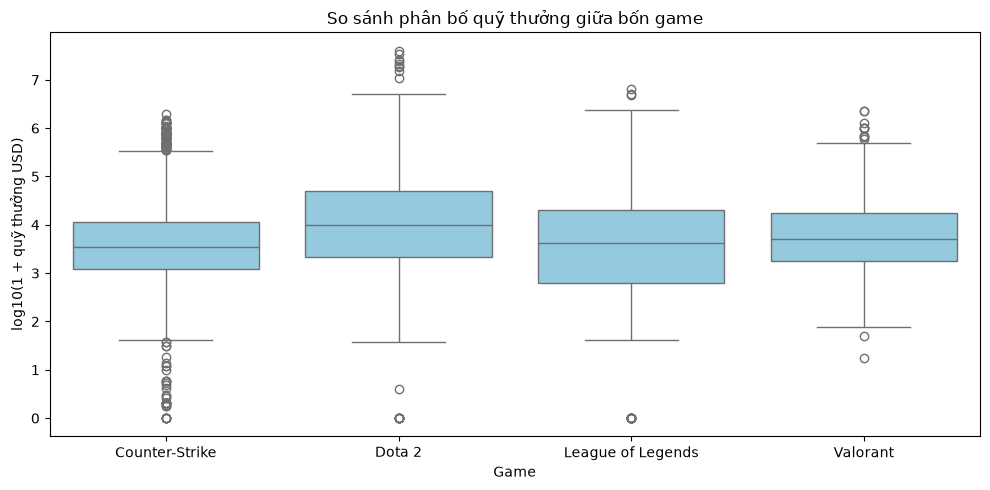

In [41]:
games = ["Counter-Strike", "Dota 2", "League of Legends", "Valorant"]
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=plot_data,
    x="game_family",
    y="log_prize",
    order=games,
    showfliers=True,
    ax=ax,
    color="skyblue",
)

ax.set_xlabel("Game")
ax.set_ylabel("log10(1 + quỹ thưởng USD)")
ax.set_title("So sánh phân bố quỹ thưởng giữa bốn game")

fig.tight_layout()
plt.show()

2.4.2

In [45]:
annual_data = eda.copy()
annual_data["year"] = annual_data["start_date"].dt.year

annual_summary = (
    annual_data.groupby(["game_family", "year"], as_index=False)
    .agg(
        so_giai=("tournament_id", "size"),
        tong_quy_thuong_usd=(
            "prize_pool_usd", lambda s: s.sum(min_count=1)
        ),
        trung_vi_quy_thuong_usd=("prize_pool_usd", "median"),
    )
    .sort_values(["game_family", "year"])
)

# Kiểm tra tổng hợp không làm mất hoặc nhân bản giải.
assert annual_summary["so_giai"].sum() == len(annual_data)

display(annual_summary.head(12).round(2))

,game_family,year,so_giai,tong_quy_thuong_usd,trung_vi_quy_thuong_usd
0,Counter-Strike,2012,51,238873.93,500.00
1,Counter-Strike,2013,198,1209002.43,1500.00
2,Counter-Strike,2014,281,2046935.93,1337.71
3,Counter-Strike,2015,722,6262230.40,1500.00
4,Counter-Strike,2016,860,17235553.52,2000.00
5,Counter-Strike,2017,930,20345426.48,2815.60
6,Counter-Strike,2018,1019,22384273.10,3000.00
7,Counter-Strike,2019,949,23295254.06,3000.00
8,Counter-Strike,2020,623,16061074.53,5957.11
9,Counter-Strike,2021,580,21932131.74,7846.20


In [46]:
annual_grid = pd.MultiIndex.from_product(
    [games, range(2012, 2026)],
    names=["game_family", "year"],
)

annual_plot = (
    annual_summary.set_index(["game_family", "year"])
    .reindex(annual_grid)
    .reset_index()
)

print("Các game–năm không có giải được ghi nhận:")
display(
    annual_plot.loc[
        annual_plot["so_giai"].isna(),
        ["game_family", "year"],
    ]
)

Các game–năm không có giải được ghi nhận:


,game_family,year
42,Valorant,2012
43,Valorant,2013
44,Valorant,2014
45,Valorant,2015
46,Valorant,2016
47,Valorant,2017
48,Valorant,2018
49,Valorant,2019


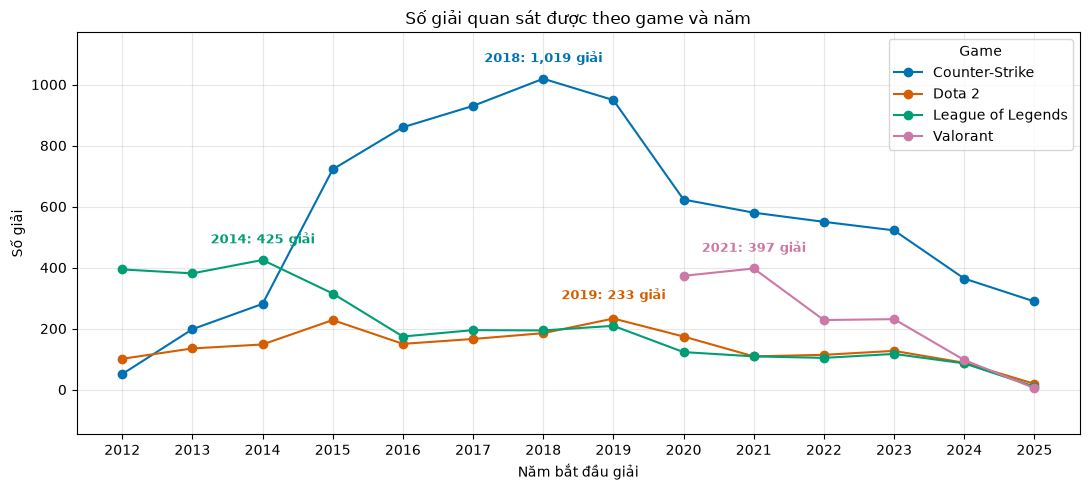

In [51]:
fig, ax = plt.subplots(figsize=(11, 5))

offsets = {
    "Counter-Strike": (0, 12),
    "Dota 2": (0, 14),
    "League of Legends": (0, 12),
    "Valorant": (0, 12),
}

for game in games:
    group = annual_plot[
        annual_plot["game_family"].eq(game)
    ].sort_values("year")

    ax.plot(
        group["year"], group["so_giai"],
        marker="o", label=game, color=colors[game],
    )

    peak = group.loc[group["so_giai"].idxmax()]

    ax.annotate(
        f'{int(peak["year"])}: {int(peak["so_giai"]):,} giải',
        xy=(peak["year"], peak["so_giai"]),
        xytext=offsets[game],
        textcoords="offset points",
        ha="center",
        color=colors[game],
        fontsize=9,
        fontweight="bold",
    )

ax.set_title("Số giải quan sát được theo game và năm")
ax.set_xlabel("Năm bắt đầu giải")
ax.set_ylabel("Số giải")
ax.set_xticks(range(2012, 2026))
ax.margins(y=0.15)
ax.legend(title="Game")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

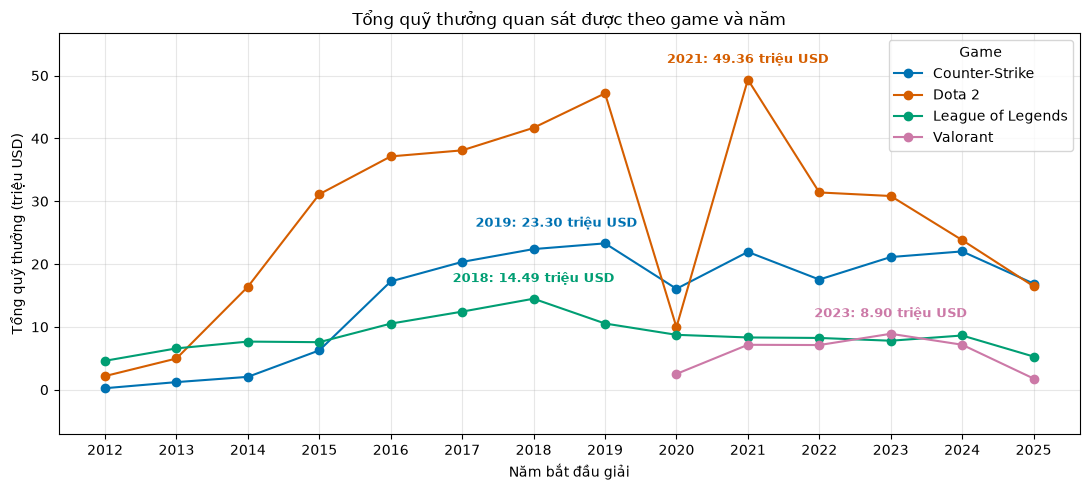

In [52]:
fig, ax = plt.subplots(figsize=(11, 5))

offsets = {
    "Counter-Strike": (-35, 12),
    "Dota 2": (0, 12),
    "League of Legends": (0, 12),
    "Valorant": (0, 12),
}

for game in games:
    group = annual_plot[
        annual_plot["game_family"].eq(game)
    ].sort_values("year")

    ax.plot(
        group["year"], group["tong_quy_thuong_usd"] / 1_000_000,
        marker="o", label=game, color=colors[game],
    )

    peak = group.loc[group["tong_quy_thuong_usd"].idxmax()]
    peak_million = peak["tong_quy_thuong_usd"] / 1_000_000

    ax.annotate(
        f'{int(peak["year"])}: {peak_million:.2f} triệu USD',
        xy=(peak["year"], peak_million),
        xytext=offsets[game],
        textcoords="offset points",
        ha="center",
        color=colors[game],
        fontsize=9,
        fontweight="bold",
    )

ax.set_title("Tổng quỹ thưởng quan sát được theo game và năm")
ax.set_xlabel("Năm bắt đầu giải")
ax.set_ylabel("Tổng quỹ thưởng (triệu USD)")
ax.set_xticks(range(2012, 2026))
ax.margins(y=0.15)
ax.legend(title="Game")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [53]:
top10_overall = eda.nlargest(10, "prize_pool_usd").copy()

display(top10_overall[[
    "source_tournament_id",
    "tournament_name",
    "game_family",
    "start_date",
    "prize_pool_usd",
]].reset_index(drop=True))

,source_tournament_id,tournament_name,game_family,start_date,prize_pool_usd
0,49174,The International 2021,Dota 2,2021-10-07,40018400.0
1,37294,The International 2019: Dota 2 Championships,Dota 2,2019-08-15,34330069.0
2,29385,The International 2018: Dota 2 Championships,Dota 2,2018-08-15,25532177.0
3,24181,The International 2017: Dota 2 Championships,Dota 2,2017-08-02,24687919.0
4,19287,The International 2016: Dota 2 Championships,Dota 2,2016-08-03,20770460.0
5,56534,The International 2022,Dota 2,2022-10-15,18930256.0
6,12894,The International 2015: Dota 2 Championships,Dota 2,2015-08-03,18429613.0
7,62667,Riyadh Masters 2023,Dota 2,2023-07-19,15120000.0
8,6418,The International 2014: Dota 2 Championships,Dota 2,2014-07-08,10931103.0
9,30411,League of Legends 2018 World Championship,League of Legends,2018-10-01,6450000.0


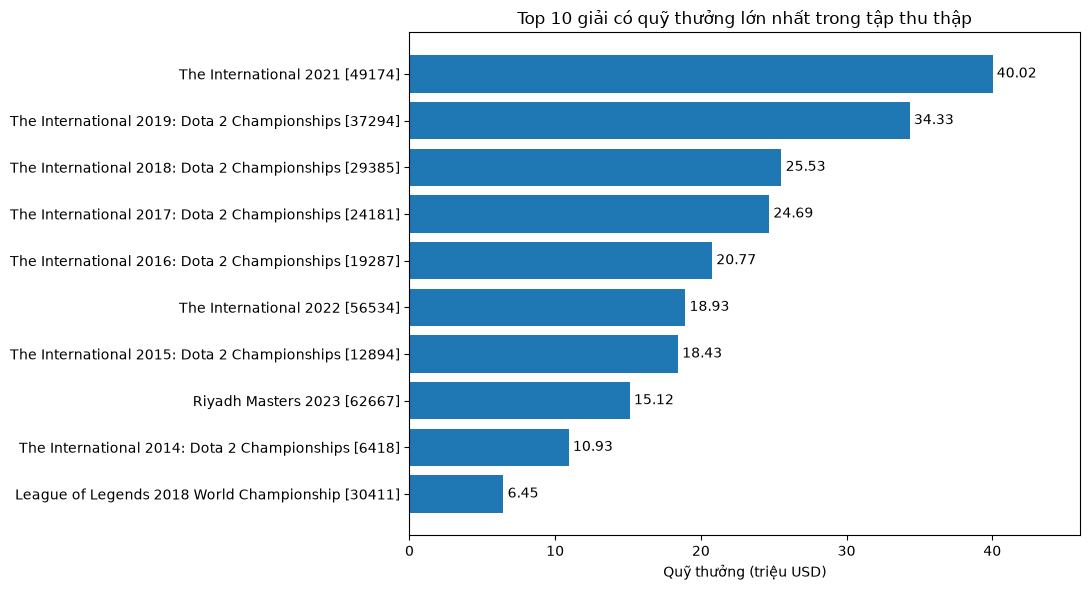

In [54]:
top10_plot = top10_overall.sort_values("prize_pool_usd").copy()

# Thêm ID để phân biệt nếu tên giải giống nhau.
top10_plot["label"] = (
    top10_plot["tournament_name"]
    + " [" + top10_plot["source_tournament_id"].astype(str) + "]"
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top10_plot["label"],
    top10_plot["prize_pool_usd"] / 1_000_000,
)

ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xlabel("Quỹ thưởng (triệu USD)")
ax.set_ylabel("")
ax.set_title("Top 10 giải có quỹ thưởng lớn nhất trong tập thu thập")
ax.margins(x=0.15)

fig.tight_layout()
plt.show()

In [55]:
concentration = (
    eda.groupby("game_family")["prize_pool_usd"]
    .agg(
        so_giai="size",
        tong_quy_thuong_usd="sum",
        top10_quy_thuong_usd=lambda s: s.nlargest(10).sum(),
    )
)

concentration["top10_share_pct"] = (
    concentration["top10_quy_thuong_usd"]
    / concentration["tong_quy_thuong_usd"] * 100
)

display(concentration.round(2))

,so_giai,tong_quy_thuong_usd,top10_quy_thuong_usd,top10_share_pct
game_family,,,,
Counter-Strike,7938,2.085726e+08,13910000.0,6.67
Dota 2,1977,3.805699e+08,213799997.0,56.18
League of Legends,2836,1.213775e+08,32017469.0,26.38
Valorant,1331,3.461111e+07,11765000.0,33.99


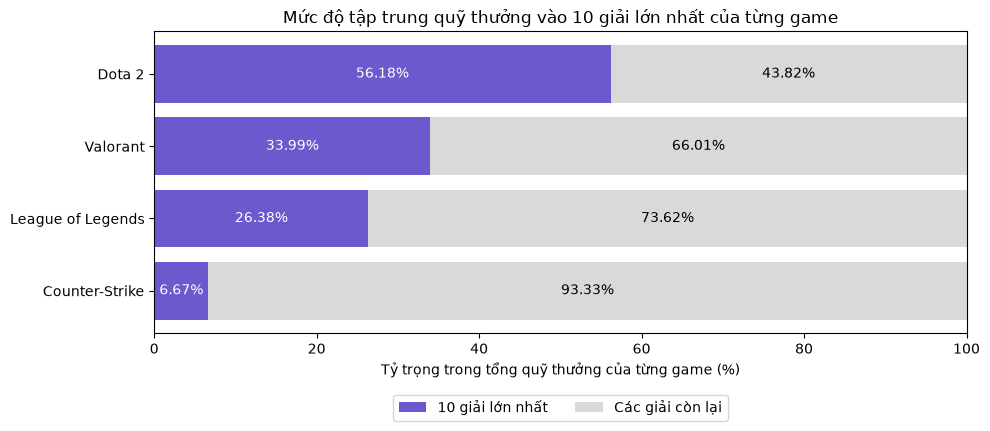

In [63]:
share = concentration["top10_share_pct"].sort_values()
remaining = 100 - share

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.barh(
    share.index, share,
    color="slateblue", label="10 giải lớn nhất",
)
ax.barh(
    share.index, remaining, left=share,
    color="#D9D9D9", label="Các giải còn lại",
)

for game, top_pct, rest_pct in zip(share.index, share, remaining):
    ax.text(
        top_pct / 2, game, f"{top_pct:.2f}%",
        ha="center", va="center", color="white", fontsize=10,
    )
    ax.text(
        top_pct + rest_pct / 2, game, f"{rest_pct:.2f}%",
        ha="center", va="center", color="black", fontsize=10,
    )

ax.set_xlim(0, 100)
ax.set_xlabel("Tỷ trọng trong tổng quỹ thưởng của từng game (%)")
ax.set_ylabel("")
ax.set_title("Mức độ tập trung quỹ thưởng vào 10 giải lớn nhất của từng game")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)

fig.tight_layout()
plt.show()

#### Thống kê phạm vi quan sát
- Phạm vi quan sát: có bao nhiêu giải theo game–năm? Không có số giải thực tế toàn thị trường làm mẫu số, nên không thể tính “đã thu thập được bao nhiêu % toàn bộ giải
- Độ nhạy theo chất lượng: khi chọn strict_quality = True, số giải và tổng quỹ thưởng thay đổi bao nhiêu?

In [65]:
coverage = (
    eda.assign(year=eda["start_date"].dt.year)
    .groupby(["game_family", "year"], as_index=False)
    .agg(so_giai=("tournament_id", "size"))
)

coverage_matrix = coverage.pivot(
    index="game_family",
    columns="year",
    values="so_giai",
)

display(coverage_matrix)

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
game_family,,,,,,,,,,,,,,
Counter-Strike,51.0,198.0,281.0,722.0,860.0,930.0,1019.0,949.0,623.0,580.0,550.0,522.0,364.0,289.0
Dota 2,101.0,135.0,148.0,228.0,150.0,166.0,185.0,233.0,174.0,109.0,114.0,127.0,88.0,19.0
League of Legends,394.0,381.0,425.0,315.0,174.0,195.0,194.0,209.0,123.0,109.0,104.0,117.0,86.0,10.0
Valorant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,373.0,397.0,228.0,231.0,97.0,5.0


#### So sánh tập đầy đủ và tập strict

In [66]:
strict_flag = (
    eda["strict_quality"].astype("string").str.strip().str.lower()
    .map({"true": True, "false": False})
)
assert strict_flag.notna().all(), "Có trạng thái strict_quality không hợp lệ."

strict_data = eda.loc[strict_flag.eq(True)].copy()

full_stats = eda.groupby("game_family").agg(
    so_giai_day_du=("tournament_id", "size"),
    quy_thuong_day_du_usd=("prize_pool_usd", "sum"),
)

strict_stats = strict_data.groupby("game_family").agg(
    so_giai_strict=("tournament_id", "size"),
    quy_thuong_strict_usd=("prize_pool_usd", "sum"),
)

sensitivity = full_stats.join(strict_stats)

sensitivity["ty_le_giai_giu_lai_pct"] = (
    sensitivity["so_giai_strict"]
    / sensitivity["so_giai_day_du"] * 100
)
sensitivity["ty_le_quy_thuong_giu_lai_pct"] = (
    sensitivity["quy_thuong_strict_usd"]
    / sensitivity["quy_thuong_day_du_usd"] * 100
)

display(sensitivity.round(2))

print("Tập đầy đủ:", len(eda), "giải")
print("Tập strict:", len(strict_data), "giải")

,so_giai_day_du,quy_thuong_day_du_usd,so_giai_strict,quy_thuong_strict_usd,ty_le_giai_giu_lai_pct,ty_le_quy_thuong_giu_lai_pct
game_family,,,,,,
Counter-Strike,7938,2.085726e+08,6794,1.886917e+08,85.59,90.47
Dota 2,1977,3.805699e+08,1842,2.625429e+08,93.17,68.99
League of Legends,2836,1.213775e+08,2647,1.008244e+08,93.34,83.07
Valorant,1331,3.461111e+07,1257,3.191963e+07,94.44,92.22


Tập đầy đủ: 14082 giải
Tập strict: 12540 giải


In [67]:
# Chuyển trạng thái về Boolean có kiểm tra.
strict_flag = (
    eda["strict_quality"].astype("string").str.strip().str.lower()
    .map({"true": True, "false": False})
)
assert strict_flag.notna().all(), "Có trạng thái strict_quality không hợp lệ."

strict_data = eda.loc[strict_flag.eq(True)].copy()

# Thống kê tập đầy đủ và tập strict theo game.
full = eda.groupby("game_family").agg(
    so_giai_day_du=("tournament_id", "size"),
    tong_tien_day_du=("prize_pool_usd", "sum"),
)

strict = strict_data.groupby("game_family").agg(
    so_giai_strict=("tournament_id", "size"),
    tong_tien_strict=("prize_pool_usd", "sum"),
)

comparison = full.join(strict)

comparison["giai_giu_lai_pct"] = (
    comparison["so_giai_strict"]
    / comparison["so_giai_day_du"] * 100
)
comparison["tien_giu_lai_pct"] = (
    comparison["tong_tien_strict"]
    / comparison["tong_tien_day_du"] * 100
)

# Bảng hiển thị: đổi tiền sang triệu USD để dễ đọc.
report_table = comparison.rename(columns={
    "so_giai_day_du": "Số giải đầy đủ",
    "so_giai_strict": "Số giải strict",
    "tong_tien_day_du": "Quỹ thưởng đầy đủ (triệu USD)",
    "tong_tien_strict": "Quỹ thưởng strict (triệu USD)",
    "giai_giu_lai_pct": "Số giải giữ lại (%)",
    "tien_giu_lai_pct": "Quỹ thưởng giữ lại (%)",
}).copy()

money_columns = [
    "Quỹ thưởng đầy đủ (triệu USD)",
    "Quỹ thưởng strict (triệu USD)",
]
report_table[money_columns] /= 1_000_000

display(report_table[[
    "Số giải đầy đủ",
    "Số giải strict",
    *money_columns,
    "Số giải giữ lại (%)",
    "Quỹ thưởng giữ lại (%)",
]].style.format({
    "Số giải đầy đủ": "{:,.0f}",
    "Số giải strict": "{:,.0f}",
    **{column: "{:,.2f}" for column in money_columns},
    "Số giải giữ lại (%)": "{:.2f}",
    "Quỹ thưởng giữ lại (%)": "{:.2f}",
}))

print(f"Tổng số giải đầy đủ: {len(eda):,}")
print(f"Tổng số giải strict: {len(strict_data):,}")

,Số giải đầy đủ,Số giải strict,Quỹ thưởng đầy đủ (triệu USD),Quỹ thưởng strict (triệu USD),Số giải giữ lại (%),Quỹ thưởng giữ lại (%)
game_family,,,,,,
Counter-Strike,"7,938","6,794",208.57,188.69,85.59,90.47
Dota 2,"1,977","1,842",380.57,262.54,93.17,68.99
League of Legends,"2,836","2,647",121.38,100.82,93.34,83.07
Valorant,"1,331","1,257",34.61,31.92,94.44,92.22


Tổng số giải đầy đủ: 14,082
Tổng số giải strict: 12,540


In [68]:
eligible = (
    eda["eligible_for_placement_prize_analysis"]
    .astype("string").str.strip().str.lower().eq("true")
)

print("Tập đầy đủ:", len(eda), "giải")
print("Đạt điều kiện placements:", int(eligible.sum()), "giải")
print("Đạt strict:", len(strict_data), "giải")

Tập đầy đủ: 14082 giải
Đạt điều kiện placements: 12713 giải
Đạt strict: 12540 giải


In [ ]:
# Xem các giải đóng góp lớn nhưng không thuộc strict
dota_non_strict = eda.loc[
    eda["game_family"].eq("Dota 2")
    & strict_flag.eq(False)
].copy()

display(
    dota_non_strict.nlargest(10, "prize_pool_usd")[[
        "tournament_name",
        "prize_pool_usd",
        "eligible_for_placement_prize_analysis",
        "quality_note",
    ]]
)

,tournament_name,prize_pool_usd,eligible_for_placement_prize_analysis,quality_note
8619,The International 2018: Dota 2 Championships,25532177.0,True,ambiguous_source_team_id
8360,The International 2017: Dota 2 Championships,24687919.0,True,ambiguous_source_team_id
8043,The International 2015: Dota 2 Championships,18429613.0,False,prize_allocation_pending_review
9598,Riyadh Masters 2023,15120000.0,False,placements_unavailable_or_unapproved
9728,Riyadh Masters 2024,5050000.0,False,placements_unavailable_or_unapproved
9434,Riyadh Masters 2022,4200000.0,False,placements_unavailable_or_unapproved
8099,The Frankfurt Major 2015,3000000.0,True,ambiguous_source_team_id
8247,The Boston Major 2016,3000000.0,True,ambiguous_source_team_id
8308,The Kiev Major 2017,3000000.0,True,ambiguous_source_team_id
8557,China Dota2 Supermajor 2018,1500000.0,True,ambiguous_source_team_id


In [71]:
# Tổng hợp nguyên nhân theo số giải và tiền thưởng
reasons = (
    dota_non_strict.assign(
        ly_do=dota_non_strict["quality_note"]
        .fillna("Không có ghi chú")
    )
    .groupby("ly_do")
    .agg(
        so_giai=("tournament_id", "size"),
        quy_thuong_usd=("prize_pool_usd", "sum"),
    )
    .sort_values("quy_thuong_usd", ascending=False)
)

reasons["quy_thuong_trieu_usd"] = reasons["quy_thuong_usd"] / 1_000_000

display(reasons[["so_giai", "quy_thuong_trieu_usd"]].round(2))

,so_giai,quy_thuong_trieu_usd
ly_do,,
ambiguous_source_team_id,71,71.87
placements_unavailable_or_unapproved,55,27.63
prize_allocation_pending_review,9,18.52
